In [1]:
import pickle
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

import morph_analyses as m

%matplotlib inline


%load_ext autoreload
%autoreload 2

In [ ]:
with open(m.params.data_dir / "morph_hists.pkl", 'rb') as file:
    morph_dict = pickle.load(file)
    
rare_dists = m.empirical_priors.prior_post(morph_dict['rare'])
freq_dists = m.empirical_priors.prior_post(morph_dict['frequent'])

In [3]:
sigma_likelihood=.3

def plot_sfreg(sessions,cmap, trial_mat_key='spks_norm', sess_key='test_sessions'):
    ut = m.unity_transforms
    u = m.utilities
    
    rare_post = rare_dists['wallmorph_posterior']
    freq_post = freq_dists['wallmorph_posterior']
    
    rare_prior = rare_dists['combined_wallmorph_prior']
    freq_prior = freq_dists['combined_wallmorph_prior']
    
    
    cmap = plt.cm.get_cmap(cmap)
    low,high = ut.inv_wallmorphx(-.3),ut.inv_wallmorphx(1.3)
    x = np.linspace(-.3,1.3,num=1000)

    f,ax = plt.subplots(2,3,figsize=[15, 10])

    rare_logpost = np.log(rare_post.T)
    ax[0,0].imshow(rare_logpost,vmin=np.percentile(rare_logpost,20),extent =[low,high,high,low],cmap='RdPu')
    ax[0,1].imshow(rare_post.T,vmin=np.percentile(rare_post,5),extent =[low,high,high,low],cmap='RdPu')
    ax[0,2].plot(ut.inv_wallmorphx(x.ravel()),rare_prior.ravel(),color='brown',linewidth=5)
    ax[0,2].plot(ut.inv_wallmorphx(x.ravel()),freq_prior.ravel(),color='blue',linewidth=5)

    freq_logpost = np.log(freq_post.T)
    ax[1,0].imshow(freq_logpost,vmin=np.percentile(freq_logpost,20),extent =[low,high,high,low],cmap='RdPu')
    ax[1,1].imshow(freq_post.T,vmin=np.percentile(freq_post,5),extent =[low,high,high,low],cmap='RdPu')
    ax[1,2].plot(ut.inv_wallmorphx(x.ravel()),freq_prior.ravel(),color='blue',linewidth=5)
    
    dkl_priors = []
    for i, (mouse, metadata) in enumerate(sessions.items()):
        sess_list = metadata[sess_key]
        if len(sess_list)==0:
            continue
        
        wallmorph, yhat = [], []
        
        
        for sess_deets in sess_list:
            if sess_key=='training_sessions':
                if sess_deets['day']==3:
                    sess = m.sess.CA1MorphSession.from_nwb(mouse, 'training', sess_deets['day'])
                else:
                    continue
            else:
                sess = m.sess.CA1MorphSession.from_nwb(mouse, 'testing', sess_deets['day'])
                    
            
            
            wallmorph.append(ut.wallmorphx(sess.trial_info['effective_morph']))
            S_trial_mat = sess.trial_matrices[trial_mat_key]
            S_trial_mat[np.isnan(S_trial_mat)]=0
            sf = m.utilities.similarity_fraction(S_trial_mat, sess.trial_info)
            yhat.append(m.similarity_fraction.sf_to_yhat(sf, sess.trial_info['morphs']))
            
        wallmorph, yhat = np.concatenate(wallmorph), np.concatenate(yhat)
            
        ax[0,0].scatter(ut.inv_wallmorphx(wallmorph),ut.inv_wallmorphx(yhat),color=cmap(float(i/len(sessions.keys()))),alpha=.5)
        ax[0,1].scatter(ut.inv_wallmorphx(wallmorph),ut.inv_wallmorphx(yhat),color=cmap(float(i/len(sessions.keys()))),alpha=.5)
        ax[1,0].scatter(ut.inv_wallmorphx(wallmorph),ut.inv_wallmorphx(yhat),color=cmap(float(i/len(sessions.keys()))),alpha=.5)
        ax[1,1].scatter(ut.inv_wallmorphx(wallmorph),ut.inv_wallmorphx(yhat),color=cmap(float(i/len(sessions.keys()))),alpha=.5)

        wmsm = u.gaussian(wallmorph[:,np.newaxis,np.newaxis],.1,x[np.newaxis,:,np.newaxis])
        yhsm = u.gaussian(yhat[:,np.newaxis,np.newaxis],.1,x[np.newaxis,np.newaxis,:])
        H = np.sum(wmsm*yhsm,axis=0)
        Z = H.sum(axis=1)
    
        H/=H.sum(axis=1,keepdims=True)
        H_prior =H.sum(axis=0)/(u.gaussian(x,sigma_likelihood, x[:,np.newaxis])/Z[:,np.newaxis]).sum(axis=1)
        H_prior /=H_prior.sum()
        
        ax[0,2].plot(ut.inv_wallmorphx(x), H_prior,color=cmap(float(i/len(sessions.keys()))))
        ax[1,2].plot(ut.inv_wallmorphx(x), H_prior,color=cmap(float(i/len(sessions.keys()))))
        
        rarekl,freqkl = sp.stats.entropy(rare_prior.ravel(),H_prior,base=2),sp.stats.entropy(freq_prior.ravel(), H_prior,base=2)
        dkl_priors.append(rarekl-freqkl)
        

   
    
    rare_map = ut.inv_wallmorphx(x[np.argmax(rare_post, axis=1)])
    ax[0,0].scatter(ut.inv_wallmorphx(x),rare_map,color='brown',zorder=100)
    ax[0,1].scatter(ut.inv_wallmorphx(x),rare_map,color='brown',zorder=100)

    freq_map = ut.inv_wallmorphx(x[np.argmax(freq_post, axis=1)])
    ax[1,0].scatter(ut.inv_wallmorphx(x),freq_map,color='blue',zorder=100)
    ax[1,1].scatter(ut.inv_wallmorphx(x),freq_map,color='blue',zorder=100)


    ax[0,0].set_xlabel("$\hat{f}_h$",fontsize=12)
    ax[0,0].set_ylabel("$f_h$",fontsize=12)
    ax[0,0].set_title("$Ideal \  Rare \ log(P(f_h|\hat{f}_h))$",fontsize=12)
    ax[0,0].set_xlim([ut.xfreq(-.11),ut.xfreq(1.11)])
    ax[0,0].set_ylim([high,low])

    ax[0,1].set_xlabel("$\hat{f}_h$",fontsize=12)
    ax[0,1].set_ylabel("$f_h$",fontsize=12)
    ax[0,1].set_title("$Ideal \  Rare \ P(f_h|\hat{f}_h)$",fontsize=12)
    ax[0,1].set_xlim([ut.xfreq(-.11),ut.xfreq(1.11)])
    ax[0,1].set_ylim([high,low])

    ax[0,2].set_xlabel("$f_h$",fontsize=12)
    ax[0,2].set_ylabel("$P(f_h)$",fontsize=12)
    ax[0,2].set_title("Reconstructed Prior vs Ideal Priors",fontsize=12)


    ax[1,0].set_xlabel("$\hat{f}_h$",fontsize=12)
    ax[1,0].set_ylabel("$f_h$",fontsize=12)
    ax[1,0].set_title("$Ideal \ Freq. \ log(P(f_h|\hat{f}_h))$",fontsize=12)
    ax[1,0].set_xlim([ut.xfreq(-.11),ut.xfreq(1.11)])
    ax[1,0].set_ylim([high,low])
#
    ax[1,1].set_xlabel("$\hat{f}_h$",fontsize=12)
    ax[1,1].set_ylabel("$f_h$",fontsize=12)
    ax[1,1].set_title("$Ideal \ Freq. \ P(f_h|\hat{f}_h)$",fontsize=12)
    ax[1,1].set_xlim([ut.xfreq(-.11),ut.xfreq(1.11)])
    ax[1,1].set_ylim([high,low])

    ax[1,2].set_xlabel("$f_h$",fontsize=12)
    ax[1,2].set_ylabel("$P(f_h)$",fontsize=12)
    ax[1,2].set_title("Reconstructed Prior vs Ideal Freq. Prior",fontsize=12)
    return f,ax, dkl_priors



/tmp/ipykernel_243498/3016983818.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap)


Text(0.5, 0.98, 'Rare sessions')

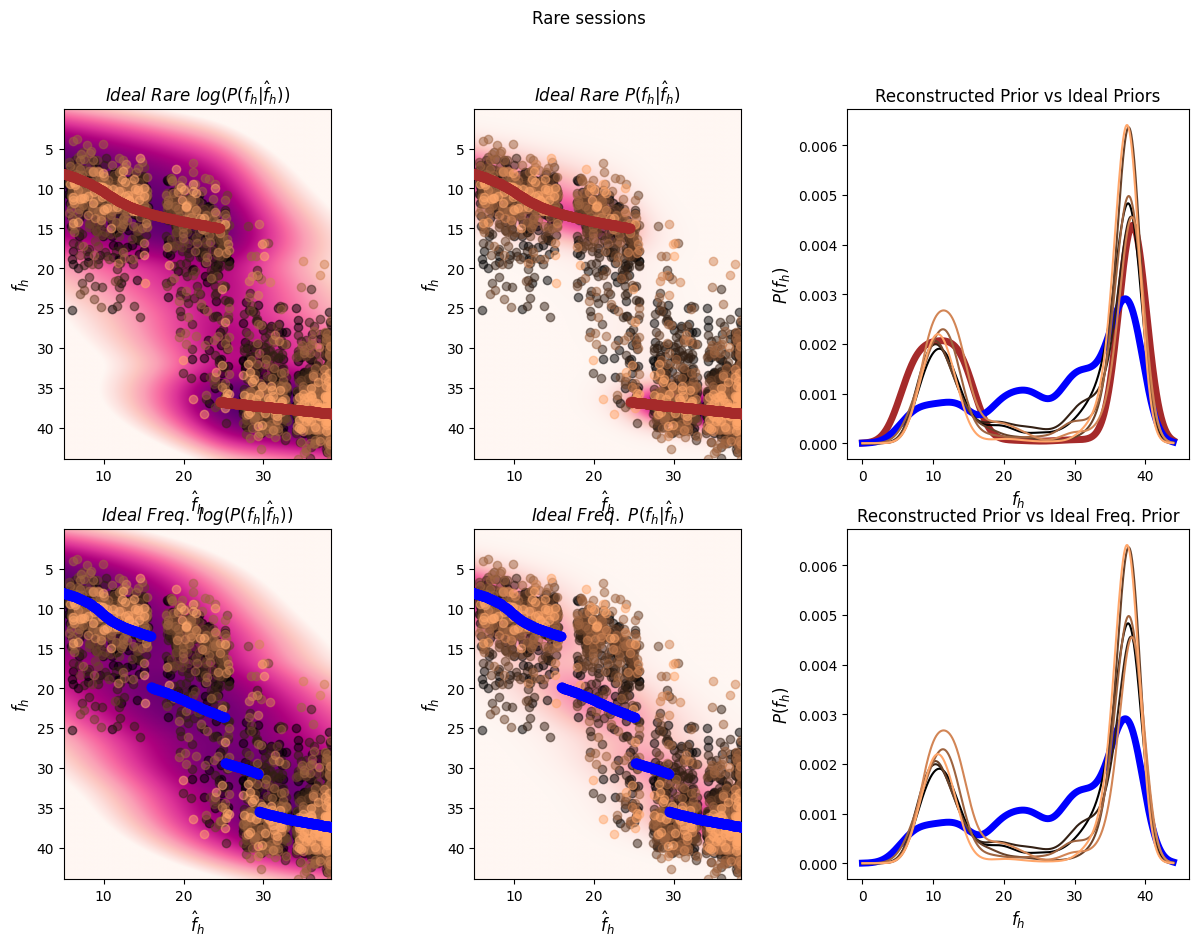

In [5]:
f,ax, rare_dkl_priors = plot_sfreg(m.mouse_metadata.rare_sessions,'copper')
f.suptitle('Rare sessions')

/tmp/ipykernel_243498/3016983818.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap)


Text(0.5, 0.98, 'Frequent sessions')

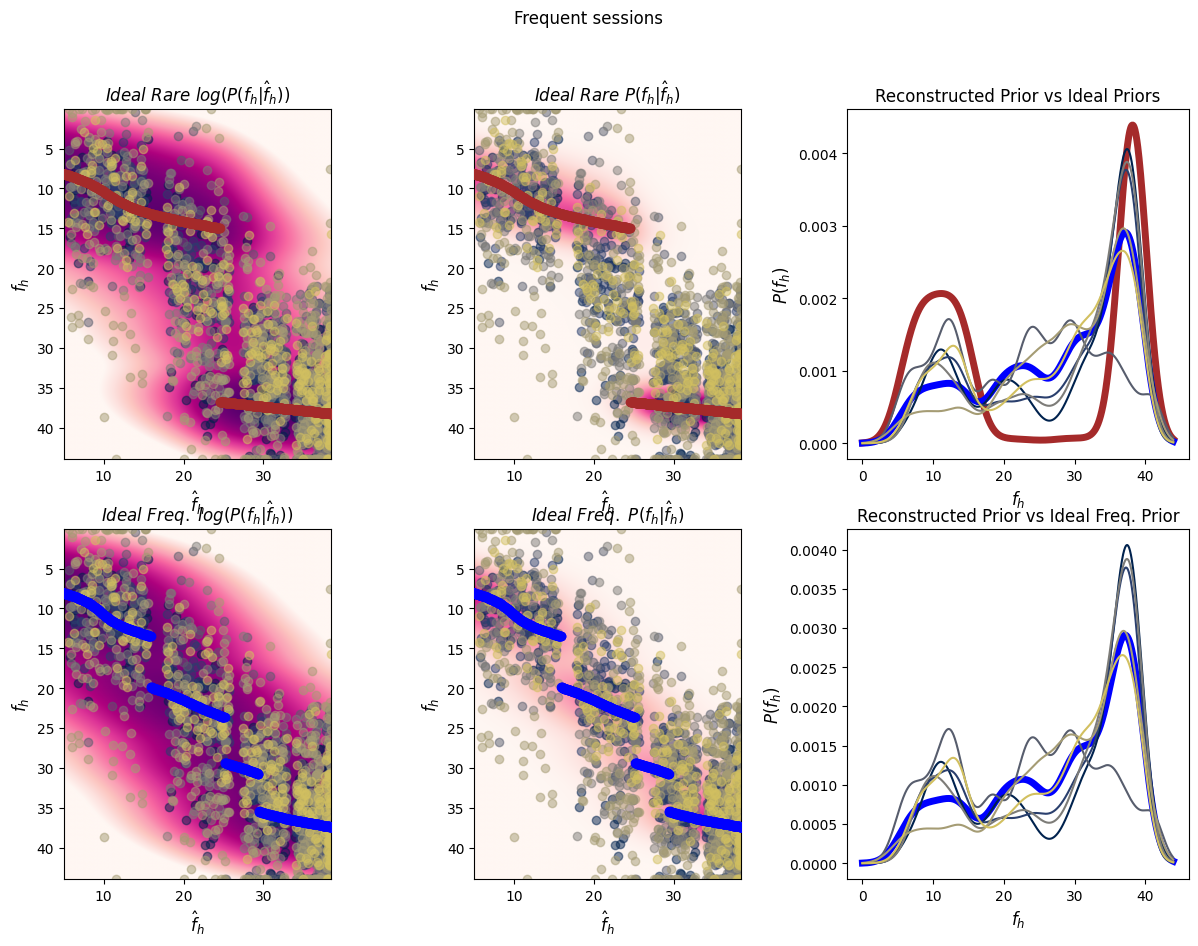

In [6]:
f,ax, freq_dkl_priors = plot_sfreg(m.mouse_metadata.frequent_sessions,'cividis')
f.suptitle('Frequent sessions')

Text(0.5, 1.0, 'Prior Reconstructions')

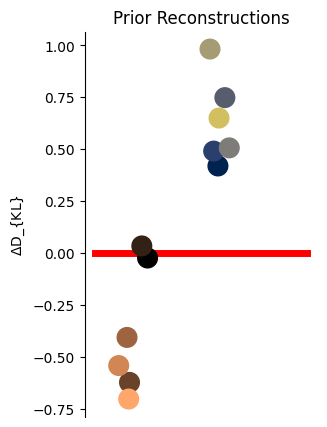

In [7]:
f,ax = plt.subplots(figsize=[3,5])
ax.scatter(-.008+np.ones([6,])+.003*np.random.rand(6),np.array(rare_dkl_priors),c = plt.cm.copper(np.arange(0,6)/6.),s=200)
ax.scatter(np.ones([6,])+.003*np.random.rand(6),np.array(freq_dkl_priors),c = plt.cm.cividis(np.arange(0,6)/6.),s=200)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot([.99,1.01],[0,0],color='red',linewidth=5,zorder=-1)

ax.set_ylabel(r'$\Delta$D_{KL}')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_title('Prior Reconstructions')

In [8]:
def get_kl_div_summary(sessions, trial_mat_key='spks_norm'):
    H = 0
    dkl = {}
    for mouse, metadata in sessions.items():
        sess_list = metadata['test_sessions']
        
        if len(sess_list)==0:
            continue
        dkl[mouse] = []
        
        H_mouse  = 0
     
        for i, sess_deets in enumerate(sess_list):
            sess = m.sess.CA1MorphSession.from_nwb(mouse, 'testing', sess_deets['day'])
            wallmorph = m.unity_transforms.wallmorphx(sess.trial_info['effective_morph'])
            trial_mat = sess.trial_matrices[trial_mat_key]
            trial_mat[np.isnan(trial_mat)]=0
            
            sf = m.utilities.similarity_fraction(trial_mat, sess.trial_info)
            yhat = m.similarity_fraction.sf_to_yhat(sf, sess.trial_info['morphs'])
            
            _H, _dkl = m.similarity_fraction.single_session_kldiv(wallmorph, yhat, morph_dict=morph_dict)
            
            H_mouse += _H
            dkl[mouse].append(_dkl)
            
        H_mouse /= i+1
        H_mouse /= H_mouse.sum(axis=1,keepdims=True)
        
        H += H_mouse
        
    H /= H.sum(axis=1, keepdims=True)
        
    return H, dkl
            
    
    

In [9]:
def H_dkl(H):
    x = np.linspace(-.3,1.3,num=1000)
    
    rare_post = rare_dists['wallmorph_posterior']
    freq_post = freq_dists['wallmorph_posterior']
    
    rare_kl,freq_kl = [],[]
    for row in range(H.shape[1]):
        if (x[row]>=.1) and (x[row]<=1.1):
            rare_kl.append(sp.stats.entropy(rare_post[row,:],H[row,:],base=2))
            freq_kl.append(sp.stats.entropy(freq_post[row,:],H[row,:],base=2))
    rare_kl,freq_kl = np.array(rare_kl),np.array(freq_kl)
    
    return np.array(rare_kl).mean()-np.array(freq_kl).mean()
    

In [10]:
rare_avgH, rare_dkl = get_kl_div_summary(m.mouse_metadata.rare_sessions)


Text(0, 0.5, '$f_h$')

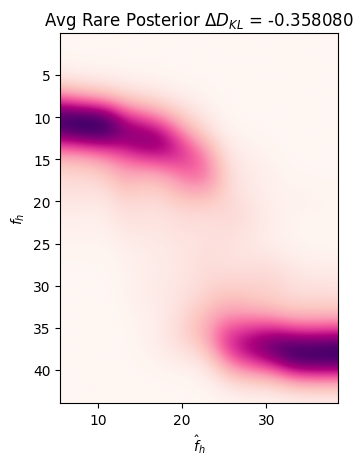

In [11]:
dkl = H_dkl(rare_avgH)
x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(rare_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Rare Posterior $\Delta D_{KL}$ = %f" % dkl)
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")

In [12]:
freq_avgH, freq_dkl = get_kl_div_summary(m.mouse_metadata.frequent_sessions)

Text(0, 0.5, '$f_h$')

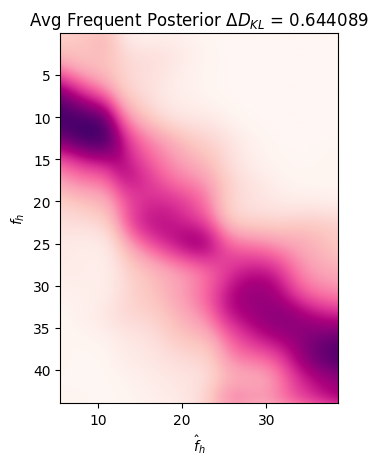

In [13]:
dkl = H_dkl(freq_avgH)
x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(freq_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Frequent Posterior $\Delta D_{KL}$ = %f" % dkl)
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")

-0.8624622891238252 0.2529624710351994
0.829955592531006 0.08378490777110997


Text(0, 0.5, '$  D_{KL}(  P_{rare}  ||  Q  ) - D_{KL} (  P_{freq}  ||  Q  ) $')

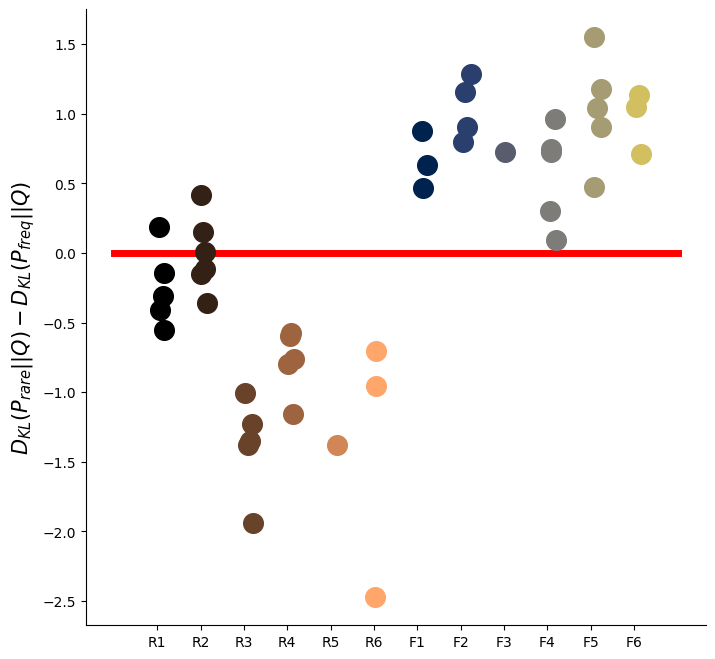

In [14]:
f,ax = plt.subplots(figsize=[8,8])
rkl = []
for i,(mouse,kl) in enumerate(rare_dkl.items()):
    dkl = np.array(kl)
    
    rkl.append(dkl.mean())
    ax.scatter(i+.25*np.random.rand(dkl.shape[0]),dkl,color=plt.cm.copper(i/6.),s=200)
print(np.mean(rkl),sp.stats.sem(rkl))
fkl = []
for j, (mouse,kl) in enumerate(freq_dkl.items()):
    dkl = np.array(kl)
   
    fkl.append(dkl.mean())
    ax.scatter(i+1+j+.25*np.random.rand(dkl.shape[0]),dkl,color=plt.cm.cividis(j/6.),s=200)
print(np.mean(fkl),sp.stats.sem(fkl))
ax.set_xticks(np.arange(j+1+i+1))
ax.set_xticklabels(['R1','R2','R3','R4','R5','R6','F1','F2','F3','F4','F5','F6'])
ax.plot([-1,12],[0,0],color='red',linewidth=5,zorder=-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("$  D_{KL}(  P_{rare}  ||  Q  ) - D_{KL} (  P_{freq}  ||  Q  ) $",fontsize=15)
# f.savefig("D:\\Morph_Results\\figures\\KLDivs\\Single_Session_Diffs.pdf",format="pdf")

## Repeat with only session 3 data

In [15]:

def get_sess3(sess_list):
    for i, sess_deets in enumerate(sess_list):
        if sess_deets['day']==3:
            ind = i
            return sess_list[i]
        else:
            pass
    return None
    
def get_sess3_kl_div_summary(sessions, trial_mat_key='spks_norm'):
    H = 0
    dkl = {}
    for mouse, metadata in sessions.items():
        dkl[mouse] = []
        sess_deets = get_sess3(metadata['training_sessions'])
        
        if sess_deets is not None:
            sess = m.sess.CA1MorphSession.from_nwb(mouse, 'training', sess_deets['day'])
            wallmorph = m.unity_transforms.wallmorphx(sess.trial_info['effective_morph'])
            trial_mat = sess.trial_matrices[trial_mat_key]
            trial_mat[np.isnan(trial_mat)]=0
            
            sf = m.utilities.similarity_fraction(trial_mat, sess.trial_info)
            yhat = m.similarity_fraction.sf_to_yhat(sf, sess.trial_info['morphs'])
            
            H_mouse, _dkl = m.similarity_fraction.single_session_kldiv(wallmorph, yhat, morph_dict=morph_dict)
            
            
            dkl[mouse].append(_dkl)            
            H += H_mouse
        
    H /= H.sum(axis=1, keepdims=True)
        
    return H, dkl
            

In [16]:
rare_sess3_avgH, rare_sess3_dkl = get_sess3_kl_div_summary(m.mouse_metadata.rare_sessions)

Text(0, 0.5, '$f_h$')

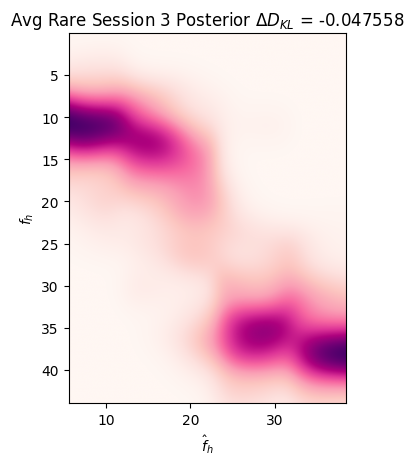

In [17]:
dkl = H_dkl(rare_sess3_avgH)
x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(rare_sess3_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Rare Session 3 Posterior $\Delta D_{KL}$ = %f" % dkl)
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")

In [18]:
freq_sess3_avgH, freq_sess3_dkl = get_sess3_kl_div_summary(m.mouse_metadata.frequent_sessions)

Text(0, 0.5, '$f_h$')

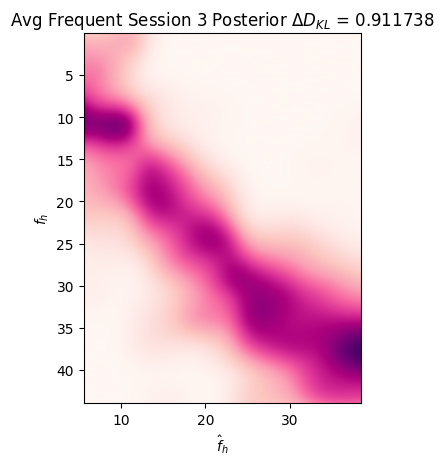

In [19]:
dkl = H_dkl(freq_sess3_avgH)
x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(freq_sess3_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Frequent Session 3 Posterior $\Delta D_{KL}$ = %f" % dkl)
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")

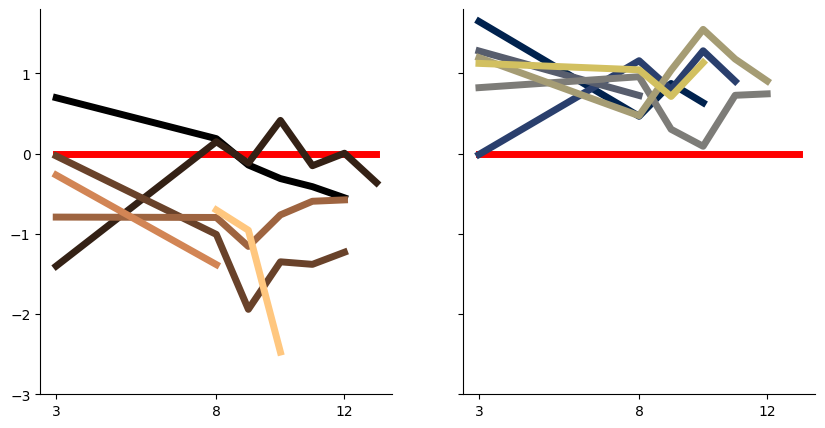

In [20]:
f,ax = plt.subplots(1,2,figsize=[10,5], sharey=True)

for i,(mouse,dkl) in enumerate(rare_dkl.items()):
    dkl = np.array(dkl)
    
    dkl0 = rare_sess3_dkl[mouse]
    if len(dkl0)>0:
        
        ax[0].plot(np.append(3,np.arange(8,8+dkl.shape[0])), np.append(dkl0[0],dkl),color=plt.cm.copper(i/6.),linewidth=5)
    else:
        ax[0].plot(np.arange(8,8+dkl.shape[0]),dkl,color=plt.cm.copper(1.),linewidth=5)
ax[0].set_ylim([-3,1.8])
ax[0].set_xticks([3,8,12])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].plot([3,13],[0,0],color='red',linewidth=5,zorder=-1)


ffskl=[]
for i,(mouse,dkl) in enumerate(freq_dkl.items()):
    dkl = np.array(dkl)
    
    
    dkl0 = freq_sess3_dkl[mouse]
    if len(dkl0)>0:
        ffskl.append(dkl0[0])
        ax[1].plot(np.append(3,np.arange(8,8+dkl.shape[0])), np.append(dkl0[0],dkl),color=plt.cm.cividis(i/6.),linewidth=5)
    else:
        ax[1].plot(np.arange(8,8+dkl.shape[0]),dkl,color=plt.cm.cividis(1.),linewidth=5)
    
    

ax[1].set_ylim([-3,1.8])
ax[1].set_xticks([3,8,12])
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].plot([3,13],[0,0],color='red',linewidth=5,zorder=-1)


/tmp/ipykernel_243498/3016983818.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap)


Text(0.5, 0.98, 'Rare sessions')

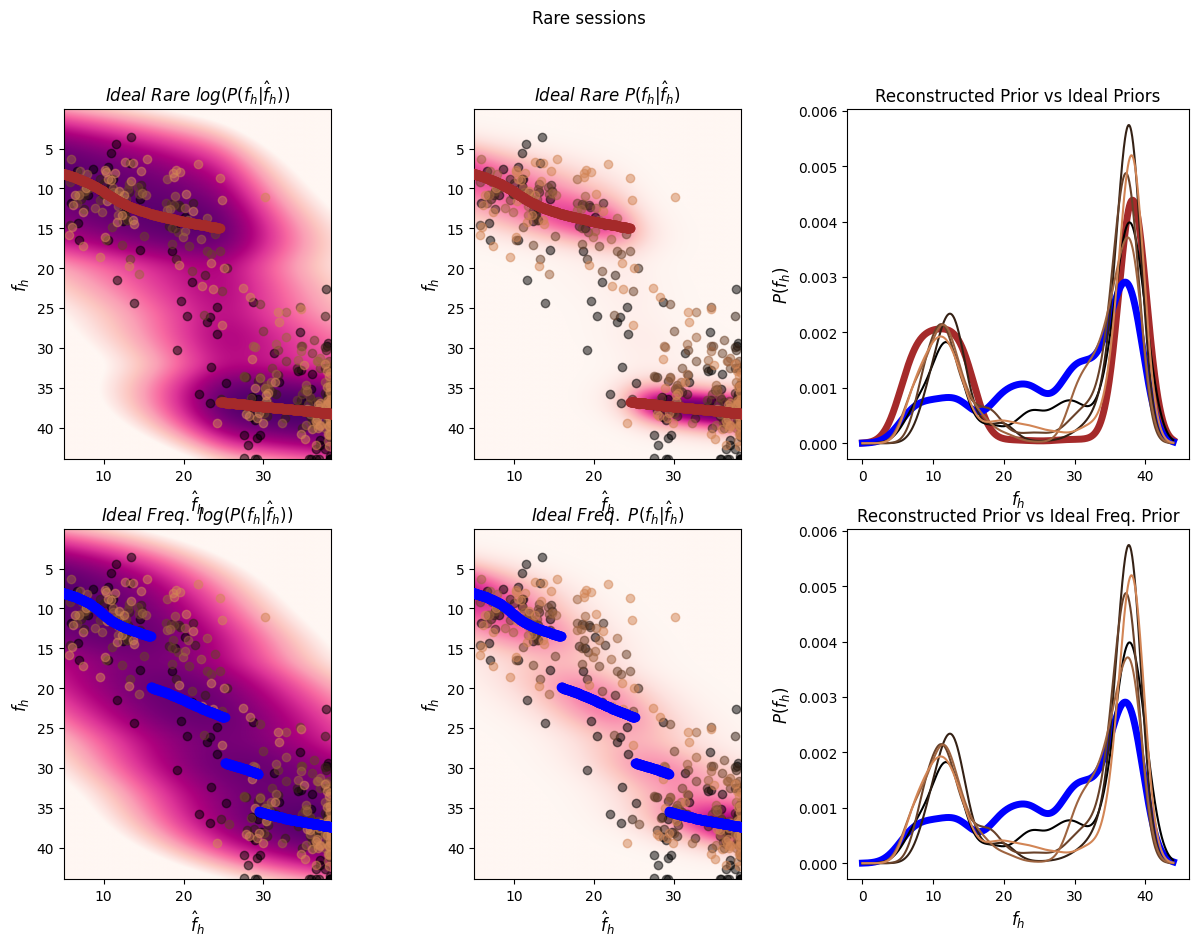

In [25]:
f,ax, rare_dkl_priors = plot_sfreg(
    m.mouse_metadata.rare_sessions,
    'copper',
    sess_key='training_sessions')
f.suptitle('Rare sessions')

/tmp/ipykernel_243498/3016983818.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap)


Text(0.5, 0.98, 'Frequent sessions')

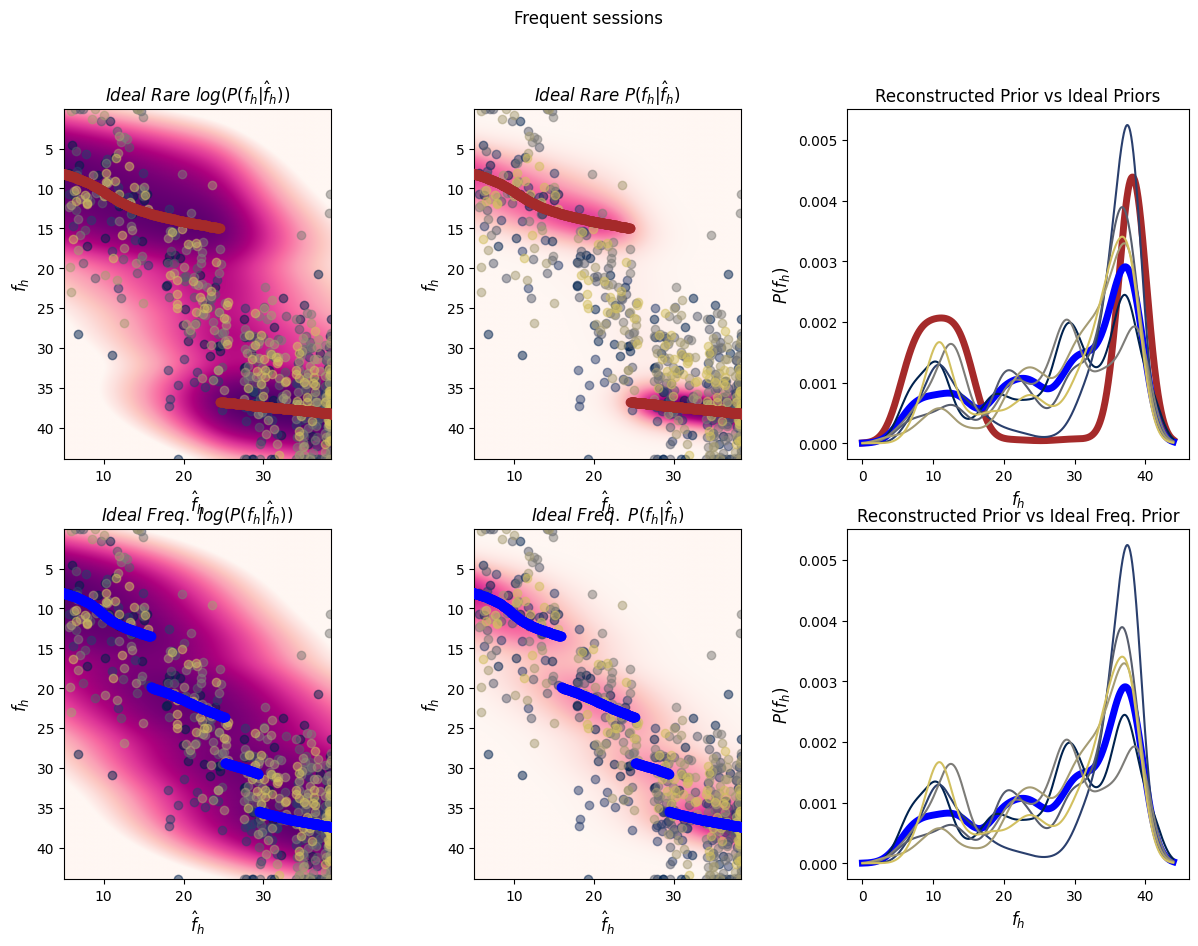

In [26]:
f,ax, freq_dkl_priors = plot_sfreg(
    m.mouse_metadata.frequent_sessions,
    'cividis',
    sess_key='training_sessions')
f.suptitle('Frequent sessions')

5


Text(0.5, 1.0, 'Session 3 Prior Reconstructions')

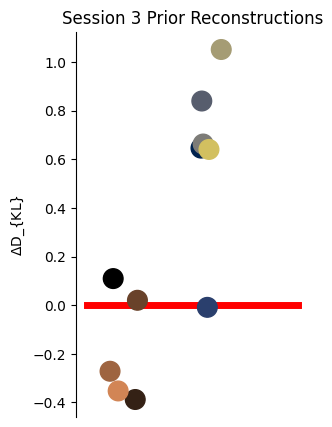

In [36]:
print(len(rare_dkl_priors))
f,ax = plt.subplots(figsize=[3,5])
ax.scatter(-.008+np.ones([5,])+.003*np.random.rand(5),np.array(rare_dkl_priors),c = plt.cm.copper(np.arange(0,5)/6.),s=200)
ax.scatter(np.ones([6,])+.003*np.random.rand(6),np.array(freq_dkl_priors),c = plt.cm.cividis(np.arange(0,6)/6.),s=200)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot([.99,1.01],[0,0],color='red',linewidth=5,zorder=-1)

ax.set_ylabel(r'$\Delta$D_{KL}')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_title('Session 3 Prior Reconstructions')

# Frequent morph with decision

/tmp/ipykernel_238884/998404314.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap)


Text(0.5, 0.98, 'Frequent with decision sessions')

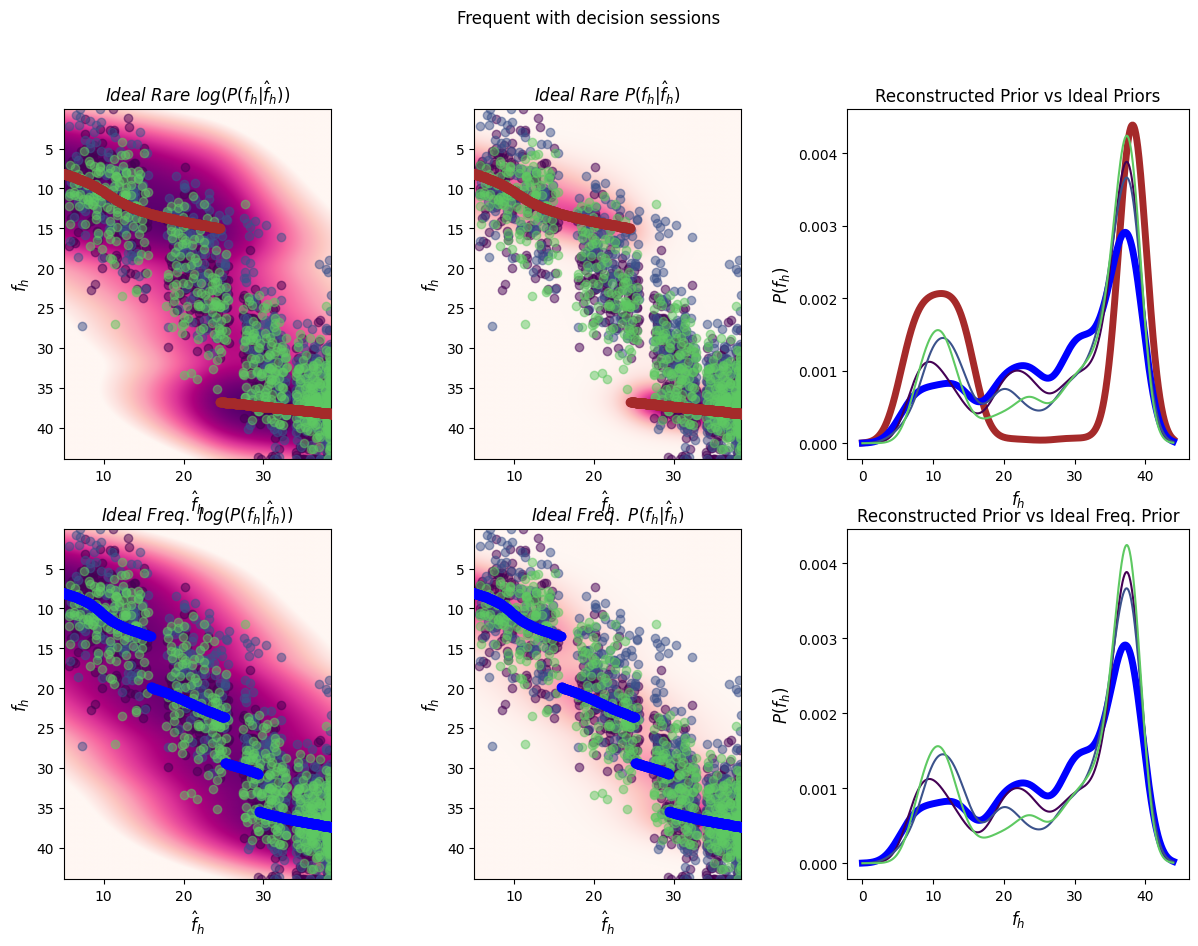

In [26]:
f,ax, fd_dkl_priors = plot_sfreg(m.mouse_metadata.frequent_w_decision_sessions,'viridis')
f.suptitle('Frequent with decision sessions')

In [29]:
freq_wd_avgH, freq_wd_dkl = get_kl_div_summary(m.mouse_metadata.frequent_w_decision_sessions)

Text(0, 0.5, '$f_h$')

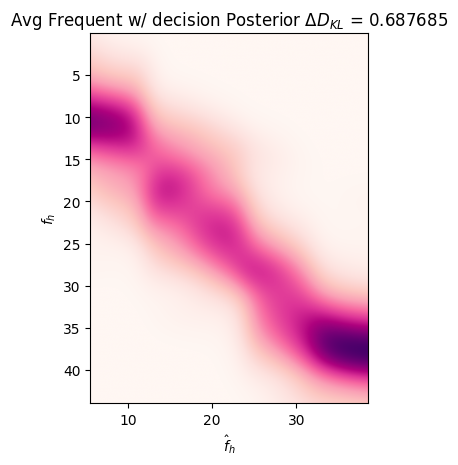

In [30]:
dkl = H_dkl(freq_wd_avgH)
x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(freq_wd_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Frequent w/ decision Posterior $\Delta D_{KL}$ = %f" % dkl)
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")